# Evaluate Basic Hairstyle Attribute Model

Evaluate the lightweight reviewed-bank attribute model for `length` and `curl`, inspect validation performance, and preview predictions on held-out samples.

In [1]:
import json
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display
from PIL import Image

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

import torch
from torch.utils.data import DataLoader

from app.ml.datasets import MultiAttributeDataset, read_jsonl_manifest
from app.ml.inference import load_hairstyle_attribute_checkpoint
from app.ml.metrics import attribute_accuracy, exact_match_accuracy
from app.ml.transforms import ResizeImage

PROJECT_ROOT

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon')

In [2]:
DATASET_ROOT = PROJECT_ROOT / 'backend' / 'data' / 'datasets' / 'reviewed_hairstyle_basic'
VAL_MANIFEST = DATASET_ROOT / 'val.jsonl'
CHECKPOINT_PATH = PROJECT_ROOT / 'backend' / 'checkpoints' / 'reviewed_hairstyle_basic' / 'basic_attribute_model.pt'

IMAGE_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

CHECKPOINT_PATH

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon/backend/checkpoints/reviewed_hairstyle_basic/basic_attribute_model.pt')

In [3]:
val_records = read_jsonl_manifest(VAL_MANIFEST)
model, inverse_vocab, core_fields, payload = load_hairstyle_attribute_checkpoint(CHECKPOINT_PATH, device=DEVICE)
label_vocab = payload['label_vocab']
history = payload.get('history', [])

print('Device:', DEVICE)
print('Validation records:', len(val_records))
print('Core fields:', core_fields)
pd.DataFrame(history)

Device: cpu
Validation records: 17
Core fields: ('length', 'curl')


,epoch,train_loss,epoch_seconds,val_loss,exact_match_accuracy,length,curl
0,1,2.248100,1.36,2.144345,0.294118,0.470588,0.411765
1,2,1.806241,1.31,1.568126,0.176471,0.411765,0.529412
2,3,1.641295,1.52,1.733687,0.411765,0.647059,0.529412
3,4,1.523528,1.50,1.687888,0.352941,0.647059,0.470588
4,5,1.347184,1.51,1.752444,0.411765,0.529412,0.705882


In [4]:
transform = ResizeImage((IMAGE_SIZE, IMAGE_SIZE))
val_dataset = MultiAttributeDataset(
    val_records,
    label_vocab=label_vocab,
    transform=transform,
    fields=core_fields,
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

batch = next(iter(val_loader))
batch['image'].shape, {field: tensor.shape for field, tensor in batch['labels'].items()}

(torch.Size([8, 3, 224, 224]),
 {'length': torch.Size([8]), 'curl': torch.Size([8])})

In [5]:
def evaluate(model, loader, device):
    model.eval()
    all_outputs = []
    all_targets = []
    all_source_ids = []

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            targets = {field: tensor.to(device) for field, tensor in batch['labels'].items()}
            outputs = model(images)
            outputs = {field: outputs[field] for field in core_fields}
            all_outputs.append({field: tensor.detach().cpu() for field, tensor in outputs.items()})
            all_targets.append({field: tensor.detach().cpu() for field, tensor in targets.items()})
            all_source_ids.extend(batch['source_id'])

    merged_outputs = {
        field: torch.cat([batch[field] for batch in all_outputs], dim=0)
        for field in core_fields
    }
    merged_targets = {
        field: torch.cat([batch[field] for batch in all_targets], dim=0)
        for field in core_fields
    }
    metrics = {
        'exact_match_accuracy': exact_match_accuracy(merged_outputs, merged_targets),
        **attribute_accuracy(merged_outputs, merged_targets),
    }
    return metrics, merged_outputs, merged_targets, all_source_ids

metrics, merged_outputs, merged_targets, source_ids = evaluate(model, val_loader, DEVICE)
pd.Series(metrics)

exact_match_accuracy    0.411765
length                  0.529412
curl                    0.705882
dtype: float64

In [6]:
rows = []
for idx, source_id in enumerate(source_ids):
    row = {'source_id': source_id}
    for field in core_fields:
        pred_index = int(merged_outputs[field][idx].argmax().item())
        true_index = int(merged_targets[field][idx].item())
        row[f'true_{field}'] = inverse_vocab[field][true_index]
        row[f'pred_{field}'] = inverse_vocab[field][pred_index]
        row[f'correct_{field}'] = row[f'true_{field}'] == row[f'pred_{field}']
    rows.append(row)

prediction_frame = pd.DataFrame(rows)
prediction_frame.head(20)

,source_id,true_length,pred_length,correct_length,true_curl,pred_curl,correct_curl
0,celeba_hair_000186,short,long,False,straight,straight,True
1,celeba_hair_000090,short,short,True,wavy,straight,False
2,celeba_hair_000088,short,short,True,straight,straight,True
3,celeba_hair_000212,long,long,True,wavy,wavy,True
4,celeba_hair_000246,long,short,False,wavy,straight,False
5,celeba_hair_000011,long,short,False,wavy,straight,False
6,celeba_hair_000161,short,short,True,curly,wavy,False
7,celeba_hair_000025,long,short,False,wavy,wavy,True
8,celeba_hair_000195,long,short,False,straight,straight,True
9,celeba_hair_000035,short,short,True,straight,straight,True


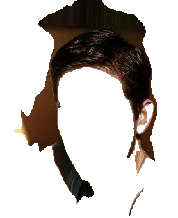

,source_id,true_length,pred_length,correct_length,true_curl,pred_curl,correct_curl
0,celeba_hair_000186,short,long,False,straight,straight,True


In [7]:
preview_root = PROJECT_ROOT / 'backend' / 'data' / 'processed' / 'celeba_hair_rich_assets' / 'images'

def show_prediction(row_index: int):
    row = prediction_frame.iloc[row_index]
    image_path = preview_root / f"{row['source_id']}.png"
    with Image.open(image_path).convert('RGBA') as image:
        display(image)
    display(row.to_frame().T)

if len(prediction_frame) > 0:
    show_prediction(0)